In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

In [2]:
using ProgressMeter
using ColorSchemes
using JLD2


In [4]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Plot lengthscales only for upgrade report

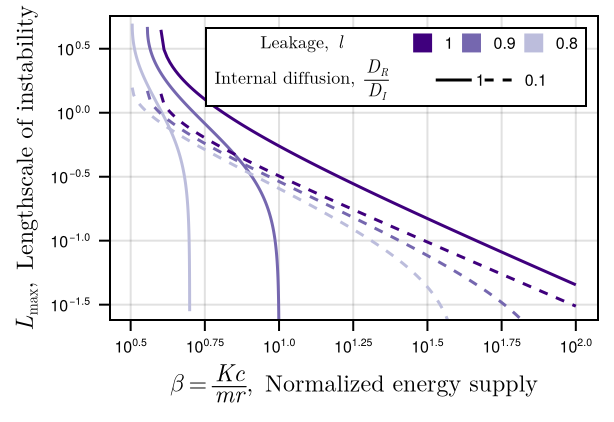

In [25]:
ls = [1., 0.9, 0.8]
ps = [1., 0.1]

lmin, lmax = extrema(ls)
ldelta = lmax - lmin
pmin, pmax = extrema(ps)
pdelta = pmax - pmin

# cc = cgrad(ColorSchemes.dense[50:end])
cc = cgrad(ColorSchemes.Purples[4:end])
# cc = cgrad(ColorSchemes.Reds[4:end])

fig = Figure(;
    # size=(double_col_width * 1.6, 1.4 * double_col_width / golden_ratio)
    size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.5),
    figure_padding=(8., 8., 8., 8.),
)
ax = Axis(fig[1,1];
    yscale=log10,
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    # xlabel=L"K,\enspace\text{Resource supply rate}",
    ylabel=L"L_\text{max},\enspace\text{Lengthscale of instability}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

for p in ps
    for l in ls
        betas = MinimalModelV2.fr2_instab_beta_range(l, p, 1000; betamax=100.)
        km2s = MinimalModelV2.fr2_km2.(betas, l, p, 1.)
        Lms = MinimalModelV2.ksquared_to_L.(km2s)
        
        lines!(ax, betas, Lms;
            label=(@sprintf "l=%.2f, p=%.2f" l p),
            linestyle=p == 1 ? :solid : :dash,
            color=get(cc, (l - lmin) / ldelta)
        )
    end
end

lmarkers = [MarkerElement(; marker=:rect, markersize=15, color=get(cc, (l - lmin) / ldelta)) for l in ls]
pmarkers = [LineElement(; linestyle=(p == 1. ? :solid : :dash)) for p in ps]
llabels = [(@sprintf "%.3g" l) for l in ls]
plabels = [(@sprintf "%.3g" p) for p in ps]

axislegend(ax,
    [lmarkers, pmarkers],
    [llabels, plabels],
    # [L"l", L"p=\frac{D_R}{D_I}"];
    [L"\text{Leakage},\enspace l", L"\text{Internal diffusion},\enspace\frac{D_R}{D_I}"];
    nbanks=3,
    # orientation=:horizontal,
    titleposition=:left,
    titlesize=6fontsize_ltex_pt,
    padding=(4., 4., 2., 0.),
    rowgap=0.,
    colgap=0.,
    patchsize=(18., 15.),
    groupgap=0.,
    patchlabelgap=2.,
    labelsize=6fontsize_pt,
)

oaoa = (0.5:0.25:2.)
ax.xticks = (10. .^ oaoa, [rich("10", superscript(string(e))) for e in oaoa])

Makie.save("../../../figures/fig3_mm_what/poster_lengths1.pdf", fig)

fig

# Testing v1
plot theory lengthscales as key bit and then put on top a couple of series from PDE final state solutions

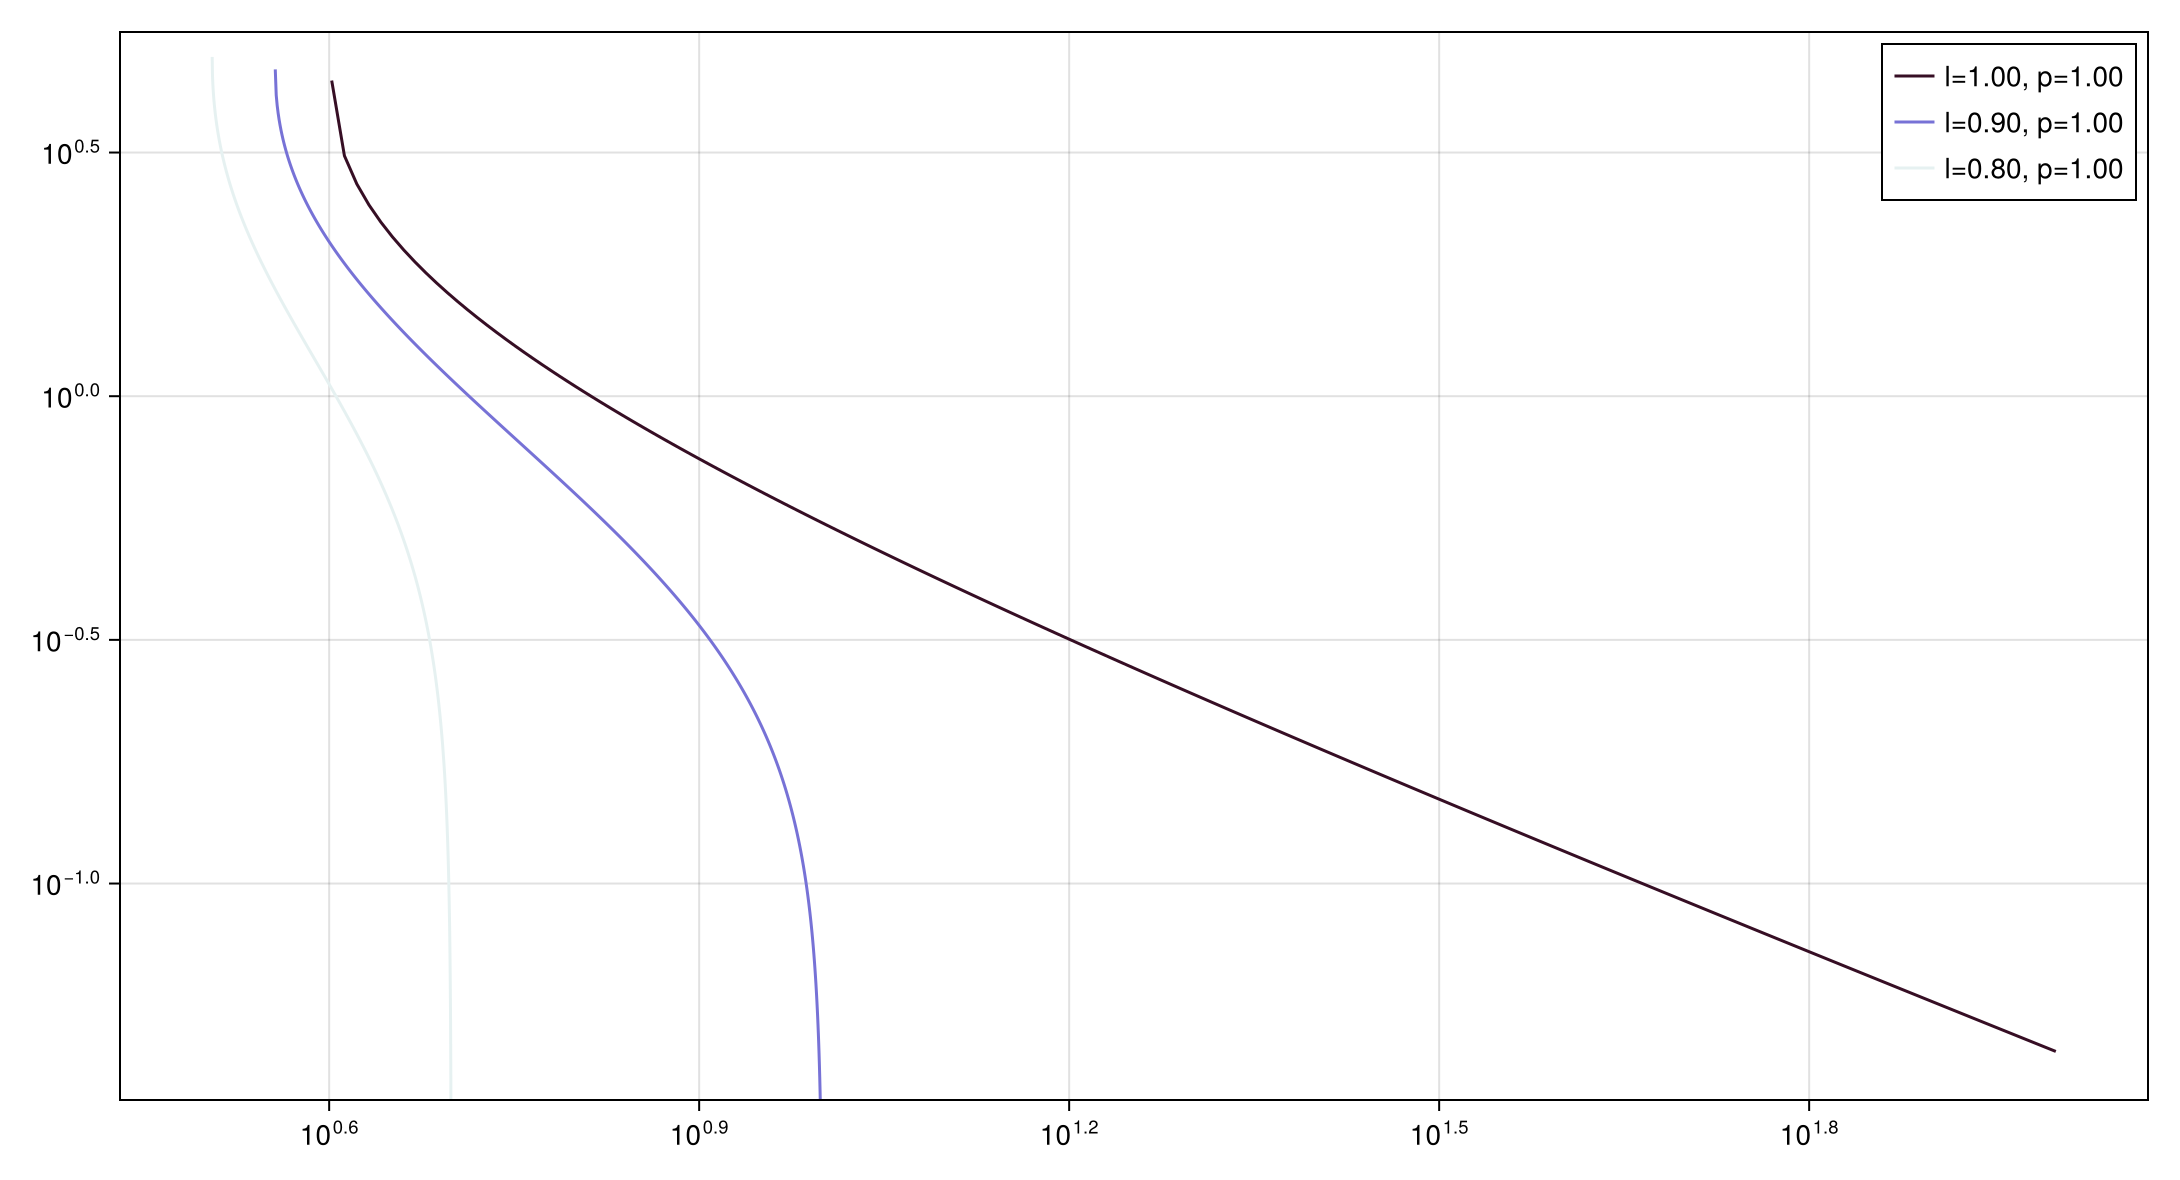

In [4]:
lps = [
    (1., 1.),
    (0.9, 1.),
    (0.8, 1.),
    # (1., 0.5),
    # (0.9, 0.5),
    # (0.8, 0.5),
    # (1., 0.1),
    # (0.8, 0.1),
    # (0.5, 0.1),
]

lmin, lmax = extrema(getindex.(lps, 1))
ldelta = lmax - lmin
pmin, pmax = extrema(getindex.(lps, 2))
pdelta = pmax - pmin

fig = Figure(;
    size=(double_col_width * 1.6, 1.4 * double_col_width / golden_ratio)
)
ax = Axis(fig[1,1];
    yscale=log10,
    xscale=log10,
)

for (l, p) in lps
    betas = MinimalModelV2.fr2_instab_beta_range(l, p, 1000; betamax=100.)
    km2s = MinimalModelV2.fr2_km2.(betas, l, p, 1.)
    Lms = MinimalModelV2.ksquared_to_L.(km2s)
    
    lines!(ax, betas, Lms;
        label=(@sprintf "l=%.2f, p=%.2f" l p),
        linestyle=p == 1 ? :solid : :dash,
        color=get(ColorSchemes.dense, (l - lmin) / ldelta)
    )
end

axislegend(ax)

fig

In [5]:
f["ls"]

LoadError: UndefVarError: `f` not defined

In [6]:
f = jldopen("../../cluster_env/runs/mm_v2_explike/v3_base1.jld2")

JLDFile /home/honza/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/cluster_env/runs/mm_v2_explike/v3_base1.jld2 (read-only)
 ├─🔢 logKs
 ├─🔢 ls
 ├─🔢 T
 ├─🔢 m
 ├─🔢 c
 ├─🔢 DN
 ├─🔢 DI
 ├─🔢 DR
 ├─🔢 N0
 └─ ⋯ (13 more entries)

In [7]:
xx = get_peaks(f);
typeof(xx)

LoadError: UndefVarError: `get_peaks` not defined

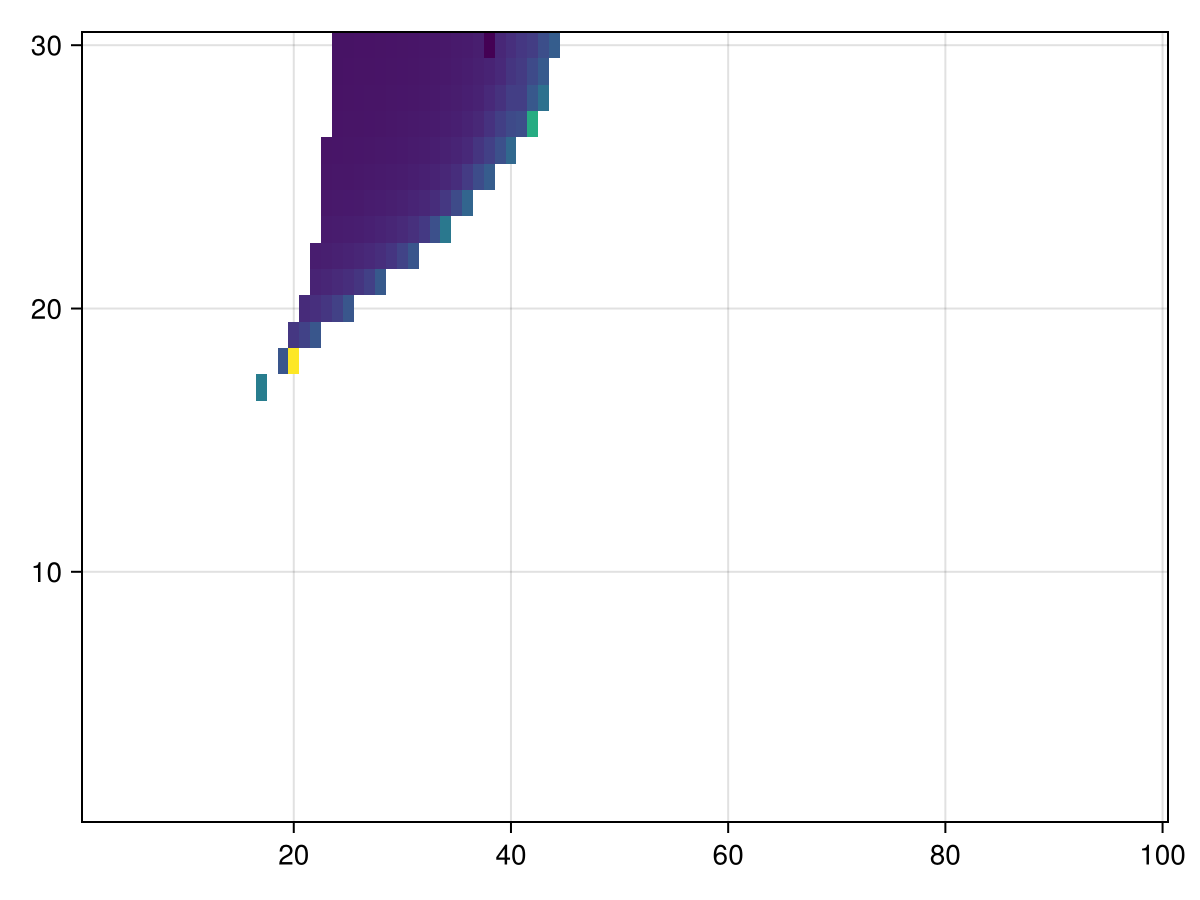

In [ ]:
heatmap(xx.avg_pkw)

In [8]:
using Peaks

In [9]:
function get_peaks(fss, dx)
    full_peaks = map(fss) do fs
        all_pks = findmaxima(fs[1, :])
        peakproms(all_pks; min=0.1)
    end
    numpeaks = map(full_peaks) do pks
        length(pks.indices)
    end
    avg_pkh = map(full_peaks) do pks
        mean(pks.heights)
    end
    avg_pkw = map(full_peaks) do pks
        if length(pks.indices) > 0
            mean(peakwidths(pks).widths) * dx
        else
            missing
        end
    end
    avg_pkp = map(full_peaks) do pks
        if length(pks.indices) > 0
            mean(peakproms(pks).proms)
        else
            missing
        end
    end
    avg_pksp = map(full_peaks) do pks
        if length(pks.indices) > 0
            spacings = pks.indices[2:end] .- pks.indices[1:end-1]
            push!(spacings, length(pks.data) + pks.indices[1] - pks.indices[end]) # periodic boundary
            mean(spacings) * dx
        else
            missing
        end
    end
    (; full_peaks, numpeaks, avg_pkh, avg_pkw, avg_pkp, avg_pksp)
end
function get_peaks(f)
    get_peaks(f["final_states"], f["L"] / f["sN"])
end


get_peaks (generic function with 2 methods)